In [2]:
import cns
import cns.data_utils as cdu
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
samples_df, cns_df = cdu.main_load("3MB")

In [12]:
cns_df = cns.group_samples(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC")))

In [13]:
def calc_angles_cons(cns_df, cn_col, norm):
    """
    Calculate angles between consecutive segments within a continuous group.
    
    Parameters
    ----------
    cns_df : pandas.DataFrame
        DataFrame containing copy number segments
    cn_col : str
        Column name containing copy number values
    norm : float
        Normalization factor for slopes
        
    Returns
    -------
    numpy.ndarray
        Array of angles between consecutive segments in radians
    """
    if (len(cns_df) < 2):
        return np.zeros(len(cns_df))
    starts = cns_df["start"].values
    ends = cns_df["end"].values
    vals = cns_df[cn_col].values
    mids = (starts + (ends - starts) // 2)
    slopes = np.diff(vals) / np.diff(mids) * norm    
    slopes_vec = np.vectorize(cns.calculate_signed_angle)
    angles = slopes_vec(slopes[1:], slopes[:-1])
    angles = np.insert(angles, 0, 0)
    angles = np.append(angles, 0)
    return angles


def calc_angles(cns_df, cn_col, norm=1):
    """
    Calculate angles between segments across the entire dataset,
    handling discontinuities appropriately.
    
    Parameters
    ----------
    cns_df : pandas.DataFrame
        DataFrame containing copy number segments
    cn_col : str
        Column name containing copy number values
    norm : float, optional
        Normalization factor for slopes, default is 1
        
    Returns
    -------
    pandas.Series
        Series of angles indexed by the original DataFrame indices
    """
    is_consecutive = cns_df["start"] - cns_df["end"].shift(1) != 0
    result = pd.Series(index=cns_df.index)
    
    for i, group_df in cns_df.groupby(is_consecutive.cumsum()):
        angle_values = calc_angles_cons(group_df, cn_col, norm=norm)
        result.loc[group_df.index] = angle_values
    
    return result

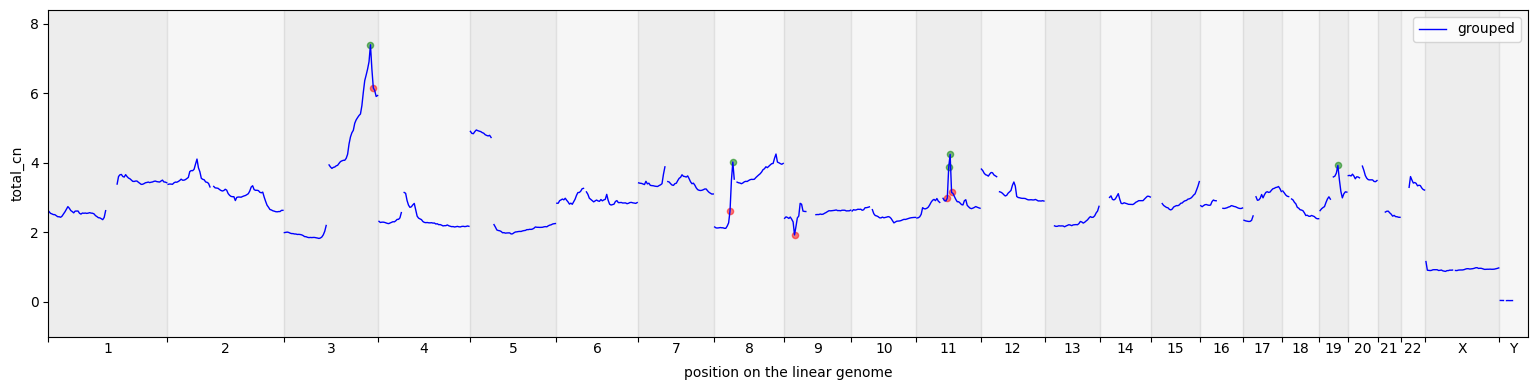

In [14]:
cns_df["score"] = calc_angles(cns_df, "total_cn", norm=1000000)

feature = "score"
val_count = 5
sorted_pos = np.argsort(cns_df[feature])
# indices of top 5 values
top_vals = sorted_pos[:val_count]
bot_vals = sorted_pos[-val_count:]

fig, ax = cns.fig_lines( cns_df, cn_columns="total_cn")
cns_df = cns.add_cum_mid(cns_df)

ax.scatter(cns_df["cum_mid"].iloc[top_vals], cns_df["total_cn"].iloc[top_vals], color='red', alpha=0.5, s=20)
ax.scatter(cns_df["cum_mid"].iloc[bot_vals], cns_df["total_cn"].iloc[bot_vals], color='green', alpha=0.5, s=20)

In [15]:
segs = cdu.load_COSMIC()

In [16]:
def get_scores_for_segs(cns_df, segs, score_col):
    """
    Calculate weighted scores for segments based on overlap with copy number segments.
    
    Parameters
    ----------
    cns_df : pandas.DataFrame
        DataFrame containing copy number segments
    segs : dict
        Dictionary mapping chromosome names to lists of segments (start, end, name)
    score_col : str
        Column name containing the scores to aggregate
        
    Returns
    -------
    pandas.DataFrame
        DataFrame with scores for each segment
    """
    scores = []
    
    # Group the data by chromosome once
    cns_by_chrom = {chrom: df.reset_index(drop=True) for chrom, df in cns_df.groupby("chrom")}
    
    for chrom, segs_list in segs.items():
        if chrom not in cns_by_chrom:
            continue
            
        chr_df = cns_by_chrom[chrom]
        
        for s_start, s_end, s_name in segs_list:
            seg_len = s_end - s_start
            
            # Find overlapping segments more efficiently
            overlaps = chr_df[(chr_df["end"] > s_start) & (chr_df["start"] < s_end)]
            
            if len(overlaps) == 0:
                scores.append([chrom, s_start, s_end, s_name, 0])
                continue
                
            # Calculate weighted score in one step
            overlap_sizes = (
                np.minimum(overlaps["end"], s_end) - 
                np.maximum(overlaps["start"], s_start)
            )
            weighted_score = np.sum(overlap_sizes * overlaps[score_col]) / seg_len
            
            scores.append([chrom, s_start, s_end, s_name, weighted_score])
            
    return pd.DataFrame(scores, columns=["chrom", "start", "end", "name", score_col])

In [17]:
scores_df = get_scores_for_segs(cns_df, segs, "score").merge(get_scores_for_segs(cns_df, segs, "total_cn"), on=["chrom", "start", "end", "name"])
scores_df["abs_score"] = scores_df["score"].abs()
scores_df["cum_mid"] = cns.calc_cum_mid(scores_df)
scores_df = scores_df.sort_values("abs_score", ascending=False)
print(scores_df.head(10))

     chrom      start        end    name      score  total_cn  abs_score  \
115  chr11   71713909   71791739   NUMA1  27.236441  4.246533  27.236441   
114  chr11   70049268   70053496    FADD  27.236441  4.246533  27.236441   
482   chr3  181429713  181432221    SOX2  22.419871  7.400855  22.419871   
621   chr8   38268655   38326352   FGFR1  19.787293  4.026116  19.787293   
112  chr11   65265232   65273940  MALAT1 -15.052043  2.989666  15.052043   
111  chr11   64570981   64578766    MEN1 -15.052043  2.989666  15.052043   
656   chr9   21967750   21995300  CDKN2A -11.791468  1.928908  11.791468   
113  chr11   69455854   69469242   CCND1   9.652429  3.880376   9.652429   
487   chr3  187439164  187463515    BCL6  -8.782138  6.161065   8.782138   
488   chr3  187871071  188608460     LPP  -8.782138  6.161065   8.782138   

        cum_mid  
115  1887660714  
114  1885959272  
482   673880961  
621  1431093193  
112  1881177476  
111  1880482763  
656  1561141237  
113  1885370438  
4

Text(0.5, 1.0, 'Top 2 genes with highest absolute change score on chr3 in LUSC')

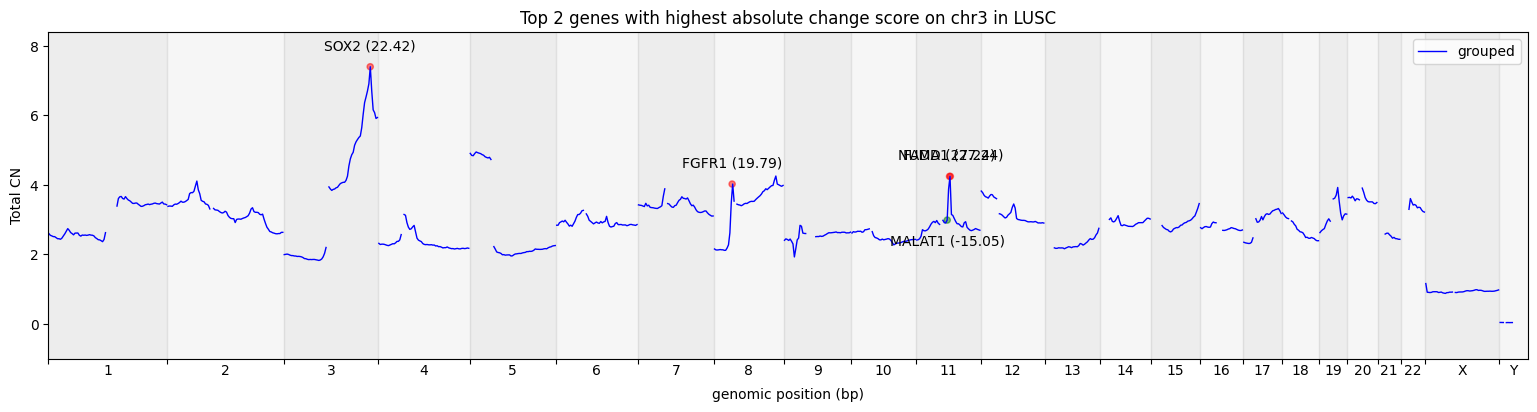

In [18]:
fig, ax = cns.fig_lines(cns_df, cn_columns="total_cn")

# scatter plot of top 5 values in scores_df, use red is score is positive, blue if negative
top_count = 5
top_genes = scores_df.head(top_count)
colors = ["red" if score > 0 else "green" for score in top_genes["score"]]
ax.scatter(top_genes["cum_mid"], top_genes["total_cn"], color=colors, alpha=0.5, s=20)

for i, row in top_genes.iterrows():
	offset = .6 * (-1 if row["score"] > 0 else 1)
	ax.text(row["cum_mid"], row["total_cn"] - offset, f'{row["name"]} ({row["score"]:.2f})', fontsize=10, ha="center", va="center")

ax.set_ylabel("Total CN")
ax.set_xlabel("genomic position (bp)")
ax.set_title("Top 2 genes with highest absolute change score on chr3 in LUSC")